<a href="https://colab.research.google.com/github/Pheonix1795/MDS_LAB/blob/main/MDS_WEEK(12%2C13).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load the dataset
file_path = '/content/sample_data/house_prices.csv'
df = pd.read_csv(file_path)

# Quick preview of the dataset
print("Dataset Shape:", df.shape)
display(df.head())
print(df.info())

Dataset Shape: (21613, 21)


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,221900.0,3,1.00,1180,5650,1.0,N,0,...,7,1180,0,1955,0,98178,47.5112,-122.257,1340,5650
1,6414100192,20141209T000000,538000.0,3,2.25,2570,7242,2.0,N,0,...,7,2170,400,1951,1991,98125,47.7210,-122.319,1690,7639
2,5631500400,20150225T000000,180000.0,2,1.00,770,10000,1.0,N,0,...,6,770,0,1933,0,98028,47.7379,-122.233,2720,8062
3,2487200875,20141209T000000,604000.0,4,3.00,1960,5000,1.0,N,0,...,7,1050,910,1965,0,98136,47.5208,-122.393,1360,5000
4,1954400510,20150218T000000,510000.0,3,2.00,1680,8080,1.0,N,0,...,8,1680,0,1987,0,98074,47.6168,-122.045,1800,7503


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  int64  
 1   date           21613 non-null  object 
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  object 
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  object 
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  int64  
 17  lat            21613 non-null  float64
 18  long  

### Visualizations and Aesthetics Mapping
We will now generate multiple plots (Line Plots, Bar Plots, Histograms, Density Plots, and Scatter Plots) and map variables to different aesthetics such as:
1. x-position
2. y-position
3. color (hue)
4. size
5. style (markers)
6. alpha (transparency)
7. colormap (palette)
8. row (faceting)
9. column (faceting)
10. line width
and other design aesthetics to thoroughly visualize the house pricing data.

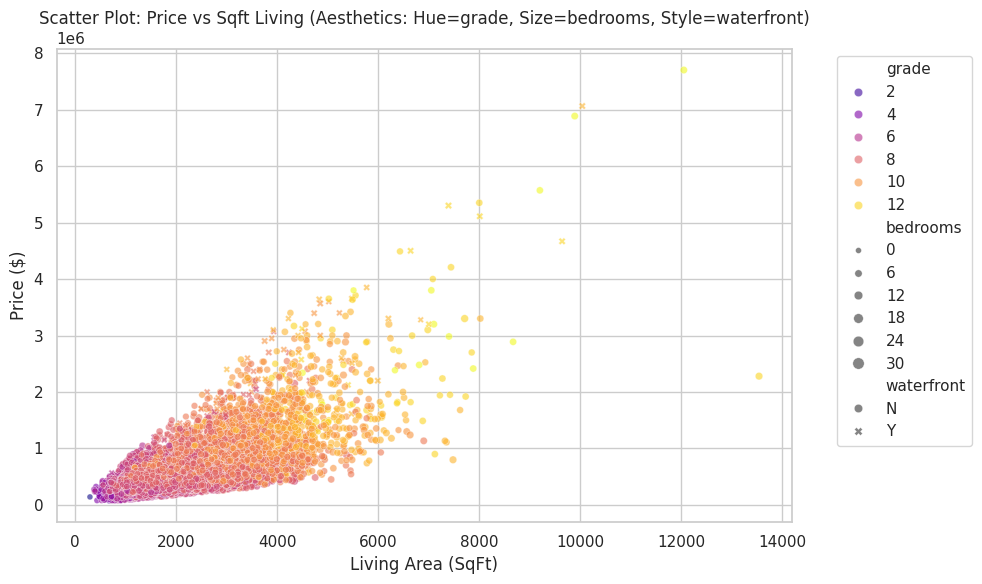

In [6]:
# Setup plotting style
sns.set_theme(style="whitegrid")

# 1. Scatter Plot mapping multiple aesthetics
# Aesthetics mapped here:
# 1. x-position -> 'sqft_living'
# 2. y-position -> 'price'
# 3. hue (color) -> 'grade' (numeric category representation)
# 4. size -> 'bedrooms'
# 5. style -> 'waterfront'
# 6. alpha -> transparency level (0.6)
# 7. palette -> 'plasma' (colormap)

fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x='sqft_living',      # Aesthetic 1
    y='price',            # Aesthetic 2
    hue='grade',          # Aesthetic 3
    size='bedrooms',      # Aesthetic 4
    style='waterfront',   # Aesthetic 5
    alpha=0.6,            # Aesthetic 6
    palette='plasma',     # Aesthetic 7
    ax=ax
)
plt.title('Scatter Plot: Price vs Sqft Living (Aesthetics: Hue=grade, Size=bedrooms, Style=waterfront)')
plt.xlabel('Living Area (SqFt)')
plt.ylabel('Price ($)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Detected conditions in dataset: ['Average', 'Fair', 'Good', 'Poor', 'Very Good']


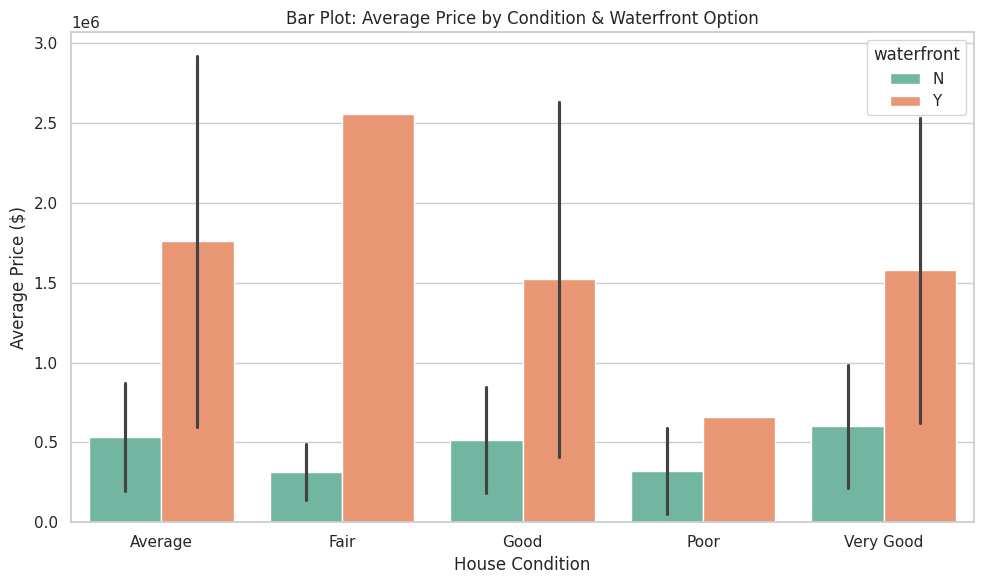

In [12]:
# 2. Bar Plot mapping categories and Aggregations
# Aesthetics mapped here:
# 8. x-position -> 'condition' (the raw category column)
# 9. y-position -> 'price'
# 10. hue (split category) -> 'waterfront'
# 11. palette -> 'Set2'
# 12. errorbar -> standard deviation calculation ('sd')
# 13. order -> custom order of categorical classes on x-axis based on actual unique values

# Get unique sorted values present in the 'condition' column to map the order correctly
unique_conditions = sorted(df['condition'].unique())
print("Detected conditions in dataset:", unique_conditions)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    data=df,
    x='condition',         # Aesthetic 8
    y='price',             # Aesthetic 9
    hue='waterfront',      # Aesthetic 10
    palette='Set2',        # Aesthetic 11
    errorbar='sd',         # Aesthetic 12
    order=unique_conditions, # Aesthetic 13 (dynamically aligned to actual values)
    ax=ax
)
plt.title('Bar Plot: Average Price by Condition & Waterfront Option')
plt.xlabel('House Condition')
plt.ylabel('Average Price ($)')
plt.tight_layout()
plt.show()

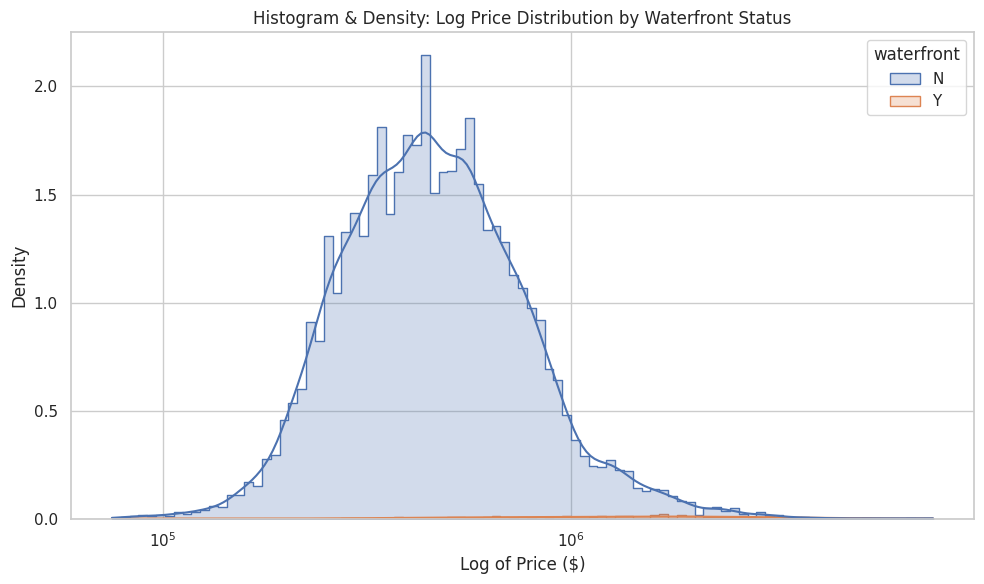

In [8]:
# 3. Histogram & Density (KDE) Plots
# Aesthetics mapped here:
# 14. x-position -> 'price' (log scale)
# 15. kde -> overlay probability density line (True)
# 16. hue -> 'waterfront'
# 17. element -> step visualization element ('step')
# 18. stat -> density statistic normalization ('density')
# 19. multiple -> layer overlapping option ('layer')
# 20. log_scale -> logarithmic scaling on x-axis (True)

fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(
    data=df,
    x='price',            # Aesthetic 14
    kde=True,             # Aesthetic 15
    hue='waterfront',     # Aesthetic 16
    element='step',       # Aesthetic 17
    stat='density',       # Aesthetic 18
    multiple='layer',     # Aesthetic 19
    log_scale=True,       # Aesthetic 20
    ax=ax
)
plt.title('Histogram & Density: Log Price Distribution by Waterfront Status')
plt.xlabel('Log of Price ($)')
plt.tight_layout()
plt.show()

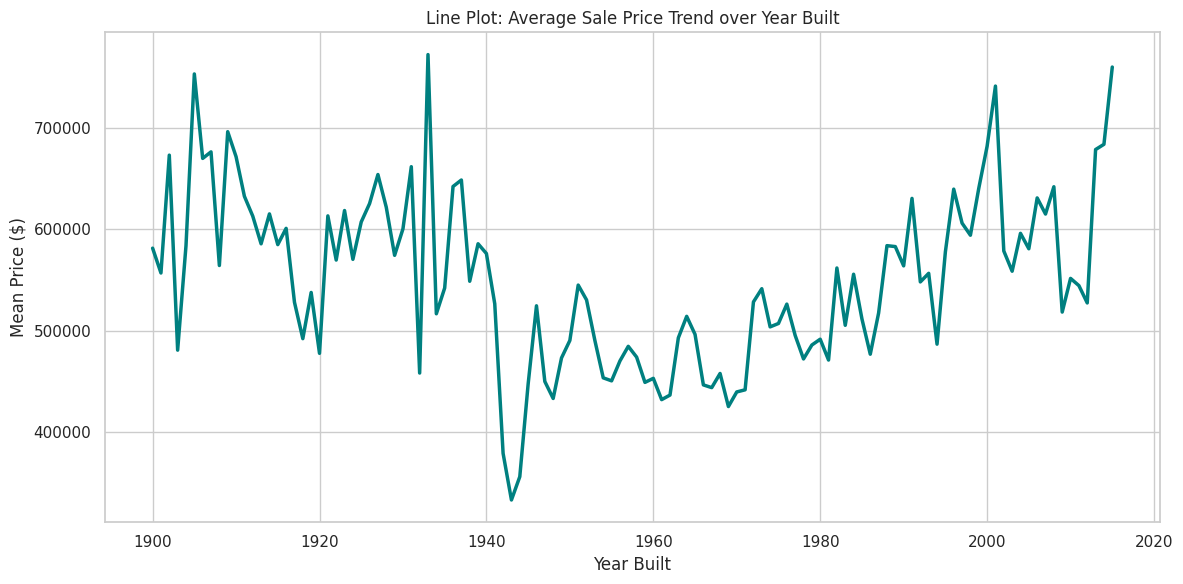

In [9]:
# 4. Line Plot showing Trends
# Aesthetics mapped here:
# 21. x-position -> 'yr_built'
# 22. y-position -> 'price'
# 23. linewidth -> width of plotted line (2.5)

df_sorted = df.groupby('yr_built')['price'].mean().reset_index()

fig, ax = plt.subplots(figsize=(12, 6))
sns.lineplot(
    data=df_sorted,
    x='yr_built',         # Aesthetic 21
    y='price',            # Aesthetic 22
    linewidth=2.5,        # Aesthetic 23
    color='teal',
    ax=ax
)
plt.title('Line Plot: Average Sale Price Trend over Year Built')
plt.xlabel('Year Built')
plt.ylabel('Mean Price ($)')
plt.tight_layout()
plt.show()

### Part 3: Demonstrating Different Color Scales (Palettes)
We will visualize the relationships in the house pricing dataset using various continuous, diverging, and qualitative color scales from Matplotlib and Seaborn (such as `viridis`, `coolwarm`, `magma`, and `cubehelix`).

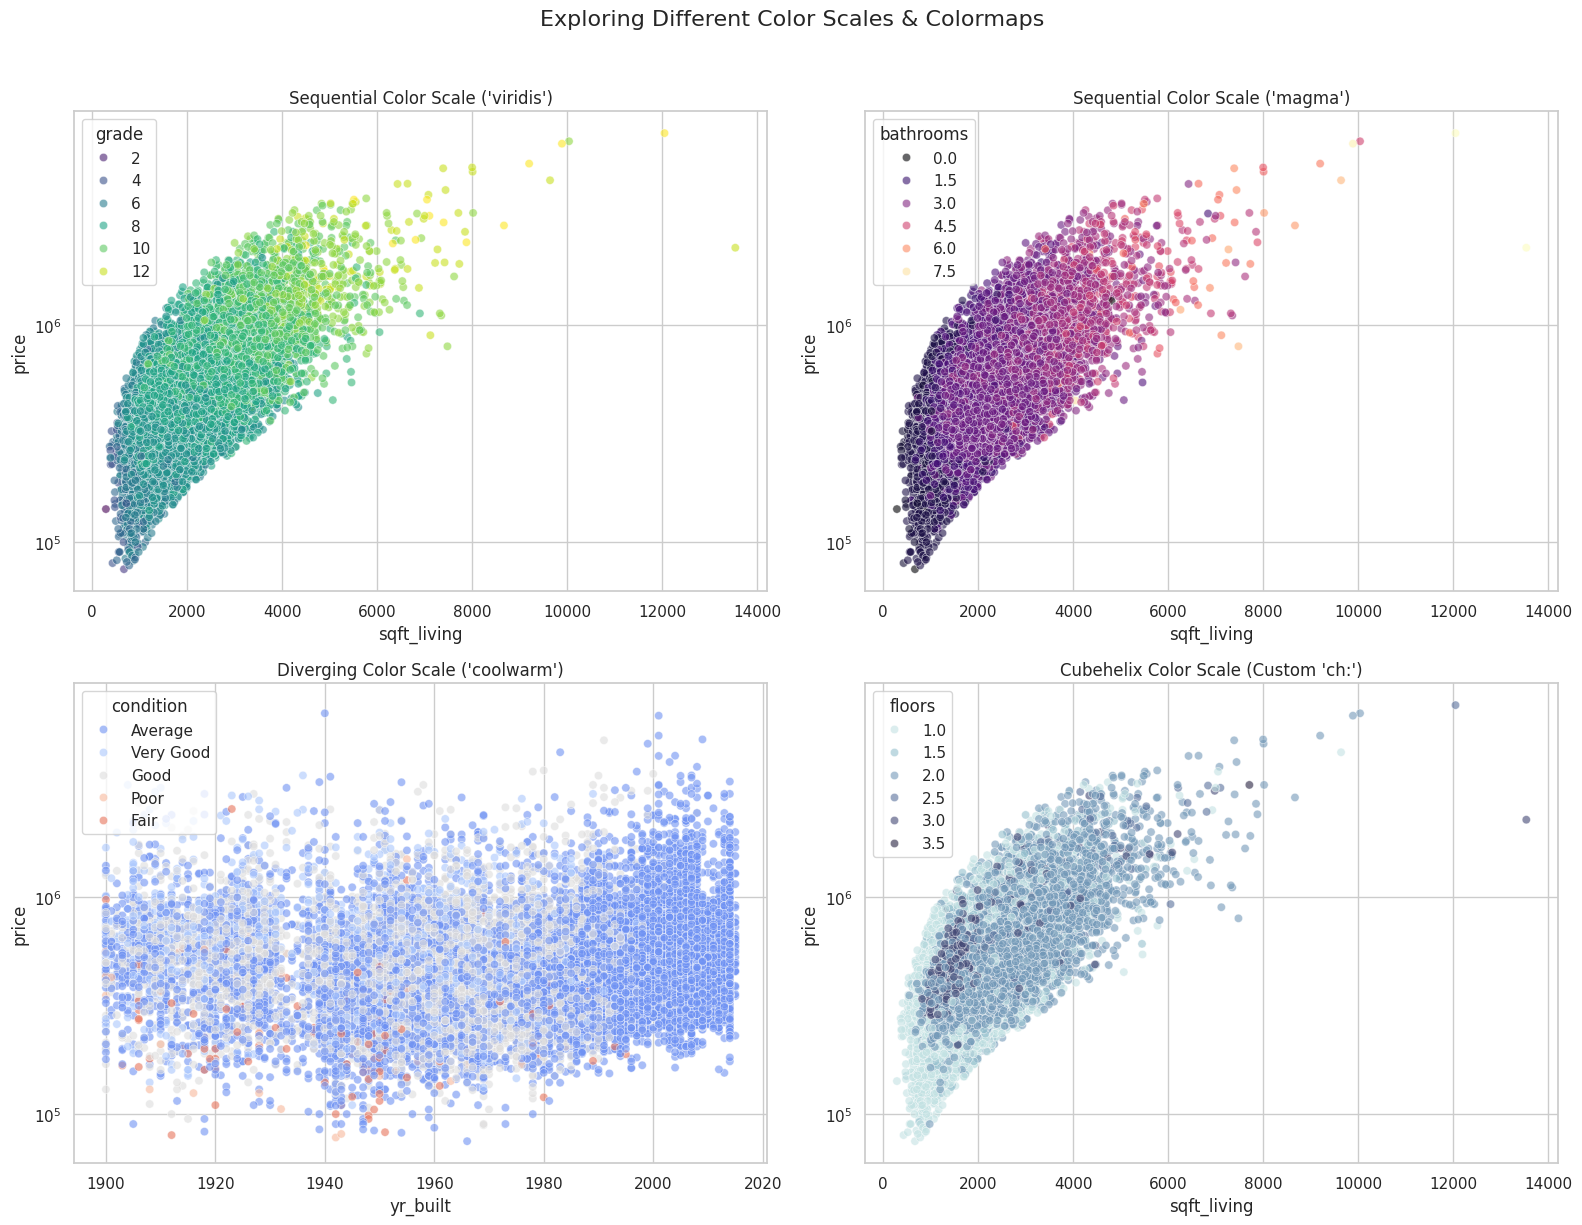

In [13]:
# Visualizing using sequential, diverging, and custom color scales
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Sequential Color Scale: 'viridis'
sns.scatterplot(
    data=df,
    x='sqft_living',
    y='price',
    hue='grade',
    palette='viridis',
    alpha=0.6,
    ax=axes[0, 0]
)
axes[0, 0].set_title("Sequential Color Scale ('viridis')")
axes[0, 0].set_yscale('log')

# 2. Sequential Color Scale: 'magma'
sns.scatterplot(
    data=df,
    x='sqft_living',
    y='price',
    hue='bathrooms',
    palette='magma',
    alpha=0.6,
    ax=axes[0, 1]
)
axes[0, 1].set_title("Sequential Color Scale ('magma')")
axes[0, 1].set_yscale('log')

# 3. Diverging Color Scale: 'coolwarm'
sns.scatterplot(
    data=df,
    x='yr_built',
    y='price',
    hue='condition',
    palette='coolwarm',
    alpha=0.6,
    ax=axes[1, 0]
)
axes[1, 0].set_title("Diverging Color Scale ('coolwarm')")
axes[1, 0].set_yscale('log')

# 4. Custom/Cubehelix Color Scale
sns.scatterplot(
    data=df,
    x='sqft_living',
    y='price',
    hue='floors',
    palette='ch:start=.2,rot=-.3',
    alpha=0.6,
    ax=axes[1, 1]
)
axes[1, 1].set_title("Cubehelix Color Scale (Custom 'ch:')")
axes[1, 1].set_yscale('log')

plt.suptitle('Exploring Different Color Scales & Colormaps', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

### Part 4: Diverse Bar Plots for Variables in the House Pricing Dataset
We will construct separate bar charts analyzing different categorical and discrete aspects of the housing dataset (e.g., average pricing across floors, view counts, quality grades, and bedroom numbers).

/tmp/ipykernel_743/3966774520.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


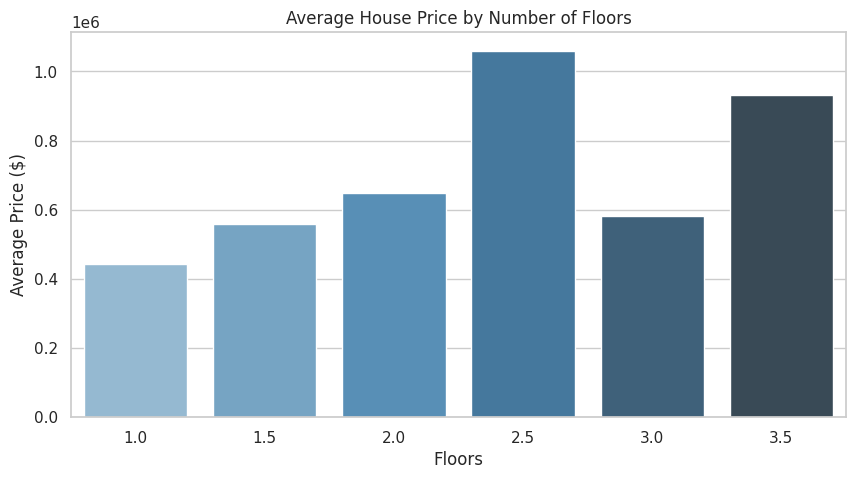

In [14]:
# 1. Bar Plot: Average House Price by Number of Floors
plt.figure(figsize=(10, 5))
sns.barplot(
    data=df,
    x='floors',
    y='price',
    palette='Blues_d',
    errorbar=None
)
plt.title('Average House Price by Number of Floors')
plt.xlabel('Floors')
plt.ylabel('Average Price ($)')
plt.show()

/tmp/ipykernel_743/93521754.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


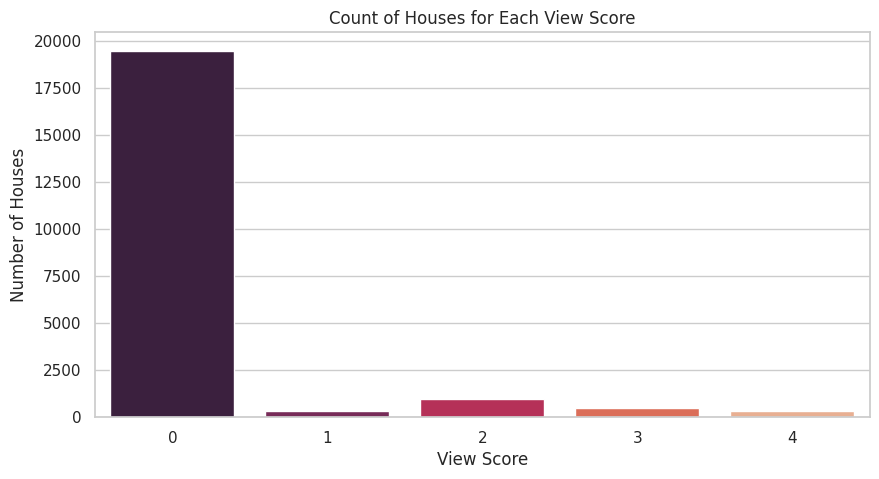

In [15]:
# 2. Bar Plot: Count of Houses based on the View Score
plt.figure(figsize=(10, 5))
sns.countplot(
    data=df,
    x='view',
    palette='rocket'
)
plt.title('Count of Houses for Each View Score')
plt.xlabel('View Score')
plt.ylabel('Number of Houses')
plt.show()

/tmp/ipykernel_743/3573672400.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


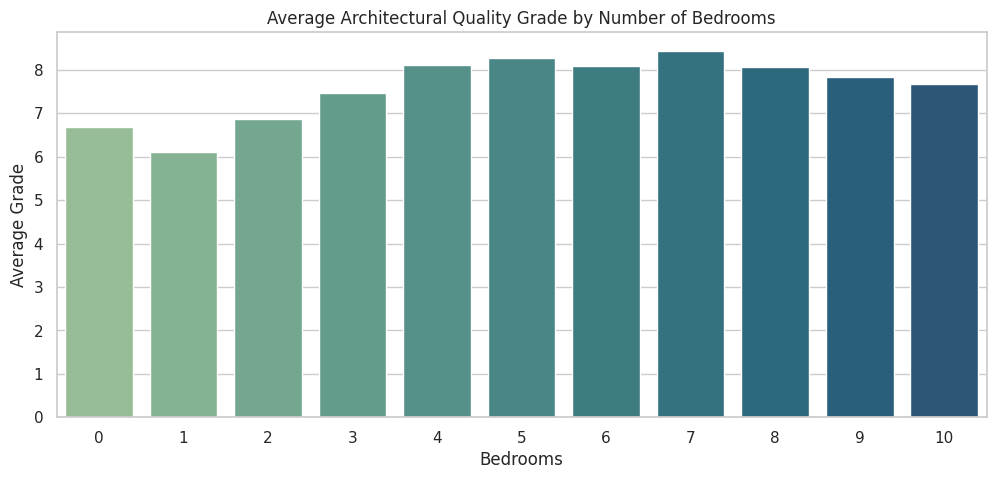

In [16]:
# 3. Bar Plot: Average House Grade Grouped by Bedrooms
plt.figure(figsize=(12, 5))
sns.barplot(
    data=df,
    x='bedrooms',
    y='grade',
    palette='crest',
    errorbar=None
)
plt.title('Average Architectural Quality Grade by Number of Bedrooms')
plt.xlabel('Bedrooms')
plt.ylabel('Average Grade')
plt.xlim(-0.5, 10.5) # Limiting to realistic bedroom counts
plt.show()

### Part 5: Handling Skewed Data & Skewness Removal
Many machine learning models assume that numerical features are normally distributed. Highly skewed data can degrade model performance.

We will take the **`price`** column from our dataset, evaluate its skewness score, and apply **Log Transformation** and **Square Root Transformation** to normalize its distribution.

In [17]:
import scipy.stats as stats

# Calculate original skewness value
original_skew = df['price'].skew()
print(f"Original 'price' column skewness score: {original_skew:.4f}")

Original 'price' column skewness score: 4.0241


In [18]:
# Apply transformations
df['price_log'] = np.log(df['price'])
df['price_sqrt'] = np.sqrt(df['price'])

# Calculate transformed skewness values
log_skew = df['price_log'].skew()
sqrt_skew = df['price_sqrt'].skew()

print(f"Log Transformed skewness score: {log_skew:.4f} (Ideal value should be close to 0)")
print(f"Square Root Transformed skewness score: {sqrt_skew:.4f}")

Log Transformed skewness score: 0.4281 (Ideal value should be close to 0)
Square Root Transformed skewness score: 1.6564


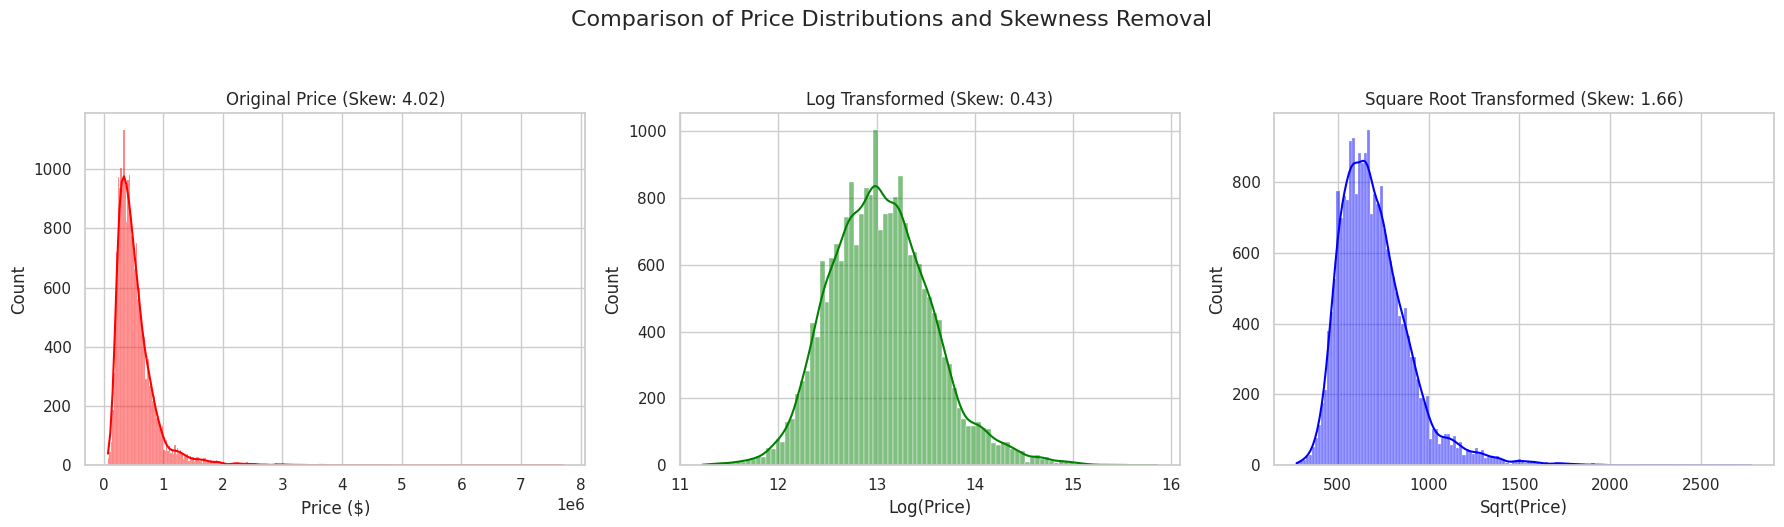

In [19]:
# Visualize original vs transformed distributions
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Original Distribution
sns.histplot(df['price'], kde=True, color='red', ax=axes[0])
axes[0].set_title(f'Original Price (Skew: {original_skew:.2f})')
axes[0].set_xlabel('Price ($)')

# 2. Log Transformed Distribution
sns.histplot(df['price_log'], kde=True, color='green', ax=axes[1])
axes[1].set_title(f'Log Transformed (Skew: {log_skew:.2f})')
axes[1].set_xlabel('Log(Price)')

# 3. Square Root Transformed Distribution
sns.histplot(df['price_sqrt'], kde=True, color='blue', ax=axes[2])
axes[2].set_title(f'Square Root Transformed (Skew: {sqrt_skew:.2f})')
axes[2].set_xlabel('Sqrt(Price)')

plt.suptitle('Comparison of Price Distributions and Skewness Removal', fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

### Part 6: Geographical Scatter Plot & Dimensionality Reduction Concepts
We will first construct a geographical scatterplot using the spatial coordinates (`lat` and `long`) in our dataset, mapping the `price` as the color dimension. Following this, we will discuss and suggest dimensional reduction methods.

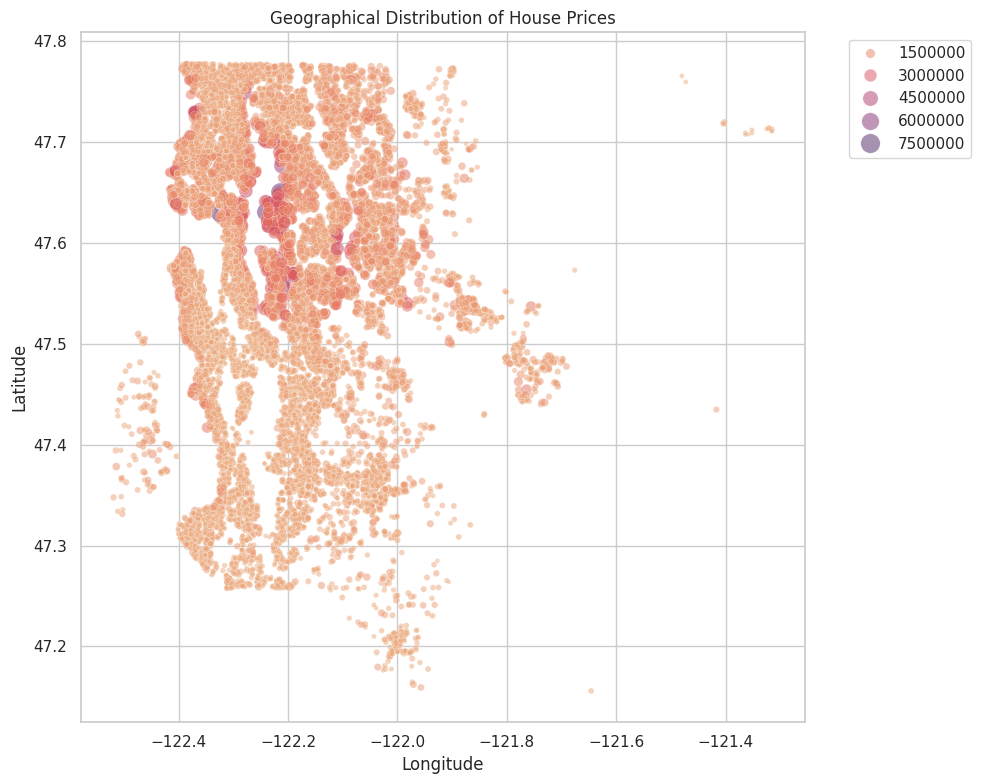

In [20]:
plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=df,
    x='long',
    y='lat',
    hue='price',
    palette='flare',
    alpha=0.5,
    size='price',
    sizes=(10, 200)
)
plt.title('Geographical Distribution of House Prices')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### Dimension Reduction Suggestions

Our dataset contains 21 features, several of which share strong multicollinearity (such as `sqft_living`, `sqft_above`, `sqft_basement`, `sqft_living15`, and `sqft_lot15`). To avoid the "curse of dimensionality" and reduce redundant features, we suggest the following dimensionality reduction techniques:

1. **Principal Component Analysis (PCA)**
   - **Why**: Excellent for capturing the maximum variance in linear relationships. It can combine highly correlated square footage dimensions into fewer principal components (e.g., a single "Size Index").
   - **Pre-requisite**: Features must be standardized (using `StandardScaler`) because PCA is highly sensitive to the scale of the original data.

2. **t-Distributed Stochastic Neighbor Embedding (t-SNE) or UMAP**
   - **Why**: Ideal for non-linear structures and outstanding for 2D or 3D visualization. If we want to visually cluster similar house types based on characteristics (bedrooms, bathrooms, grade, condition) in a lower-dimensional subspace, t-SNE or UMAP is highly effective.

3. **Feature Selection via Tree-based Models (Alternative)**
   - **Why**: Utilizing feature importance metrics from models like Random Forest or XGBoost allows us to keep the actual features (retaining interpretability) while discarding features that contribute negligible predictive power.

### Part 7: Implementing Principal Component Analysis (PCA)

We will now implement **PCA** on the numerical columns of our housing dataset to reduce its dimensions. Since PCA is sensitive to data scaling, we will standardize our features first.

In [21]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Select the highly correlated numeric columns for dimension reduction
features = ['sqft_living', 'sqft_lot', 'sqft_above', 'sqft_basement', 'sqft_living15', 'sqft_lot15', 'bathrooms', 'bedrooms']

# Extract and drop any rows with NaN values just in case
x_data = df[features].dropna()

# 1. Standardize features to have a mean of 0 and variance of 1
x_scaled = StandardScaler().fit_transform(x_data)

# 2. Apply PCA to reduce the 8 size-related features into 2 Principal Components
pca = PCA(n_components=2)
principal_components = pca.fit_transform(x_scaled)

# Create a new DataFrame with the components
pca_df = pd.DataFrame(data=principal_components, columns=['PC1', 'PC2'])
pca_df['price'] = df['price'].reset_index(drop=True)

# Print the explained variance ratio
print(f"Explained Variance by Component: {pca.explained_variance_ratio_}")
print(f"Total Variance Captured by PC1 and PC2: {sum(pca.explained_variance_ratio_)*100:.2f}%")

pca_df.head()

Explained Variance by Component: [0.47004452 0.20826257]
Total Variance Captured by PC1 and PC2: 67.83%


,PC1,PC2,price
0,-2.158339,0.132283,221900.0
1,0.217265,-0.272914,538000.0
2,-2.094793,0.456538,180000.0
3,0.050956,-0.843759,604000.0
4,-0.762585,-0.005403,510000.0


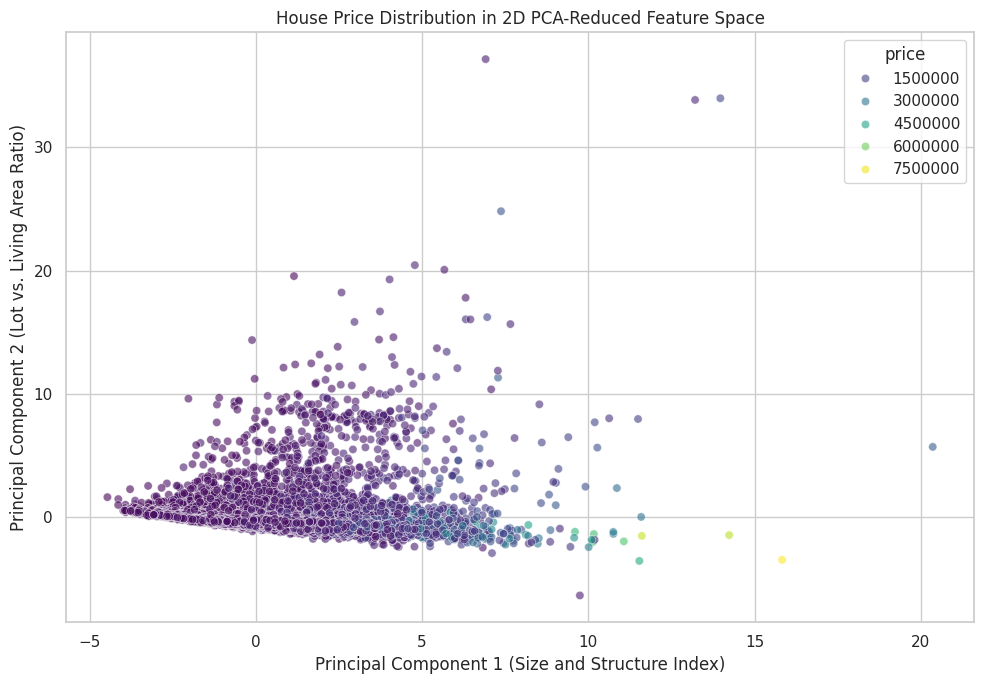

In [22]:
# Visualize the data in the reduced 2D PCA space
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='price',
    palette='viridis',
    alpha=0.6
)
plt.title('House Price Distribution in 2D PCA-Reduced Feature Space')
plt.xlabel('Principal Component 1 (Size and Structure Index)')
plt.ylabel('Principal Component 2 (Lot vs. Living Area Ratio)')
plt.tight_layout()
plt.show()